<a href="https://colab.research.google.com/github/Marina4ij/Dz5/blob/main/Dz5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
pip install pandas numpy scikit-learn xgboost lightgbm catboost matplotlib seaborn

 Laptop Price (Kaggle)

визуализация остатков моделей

ЗАГРУЗКА ДАННЫХ
Размер датасета: 1303 строк, 12 столбцов
Train: 1042, Test: 261

ОБУЧЕНИЕ МОДЕЛЕЙ И РАСЧЕТ ОСТАТКОВ
Обучение: Linear Regression... R2 = 0.8138
Обучение: Ridge... R2 = 0.8135
Обучение: Lasso... R2 = 0.8113
Обучение: Elastic Net... R2 = 0.8255
Обучение: Bayesian Ridge... R2 = 0.8259
Обучение: Huber Regressor... R2 = 0.8292
Обучение: Orthogonal Matching Pursuit... R2 = 0.7890
Обучение: Passive Aggressive... R2 = 0.8317
Обучение: KNN... R2 = 0.7105
Обучение: Dummy Regressor... R2 = -0.0011
Обучение: Decision Tree... R2 = 0.6800
Обучение: Random Forest... R2 = 0.7877
Обучение: Extra Trees... R2 = 0.8009
Обучение: Gradient Boosting... R2 = 0.8087
Обучение: AdaBoost... R2 = 0.6785
Обучение: XGBoost... R2 = 0.7968
Обучение: LightGBM... R2 = 0.7478
Обучение: CatBoost... R2 = 0.7623
Обучение: Ensemble (Voting)... R2 = 0.7897

СОЗДАНИЕ ГРАФИКОВ ОСТАТКОВ
✓ Сохранен: laptop_residuals_grid_top12.png


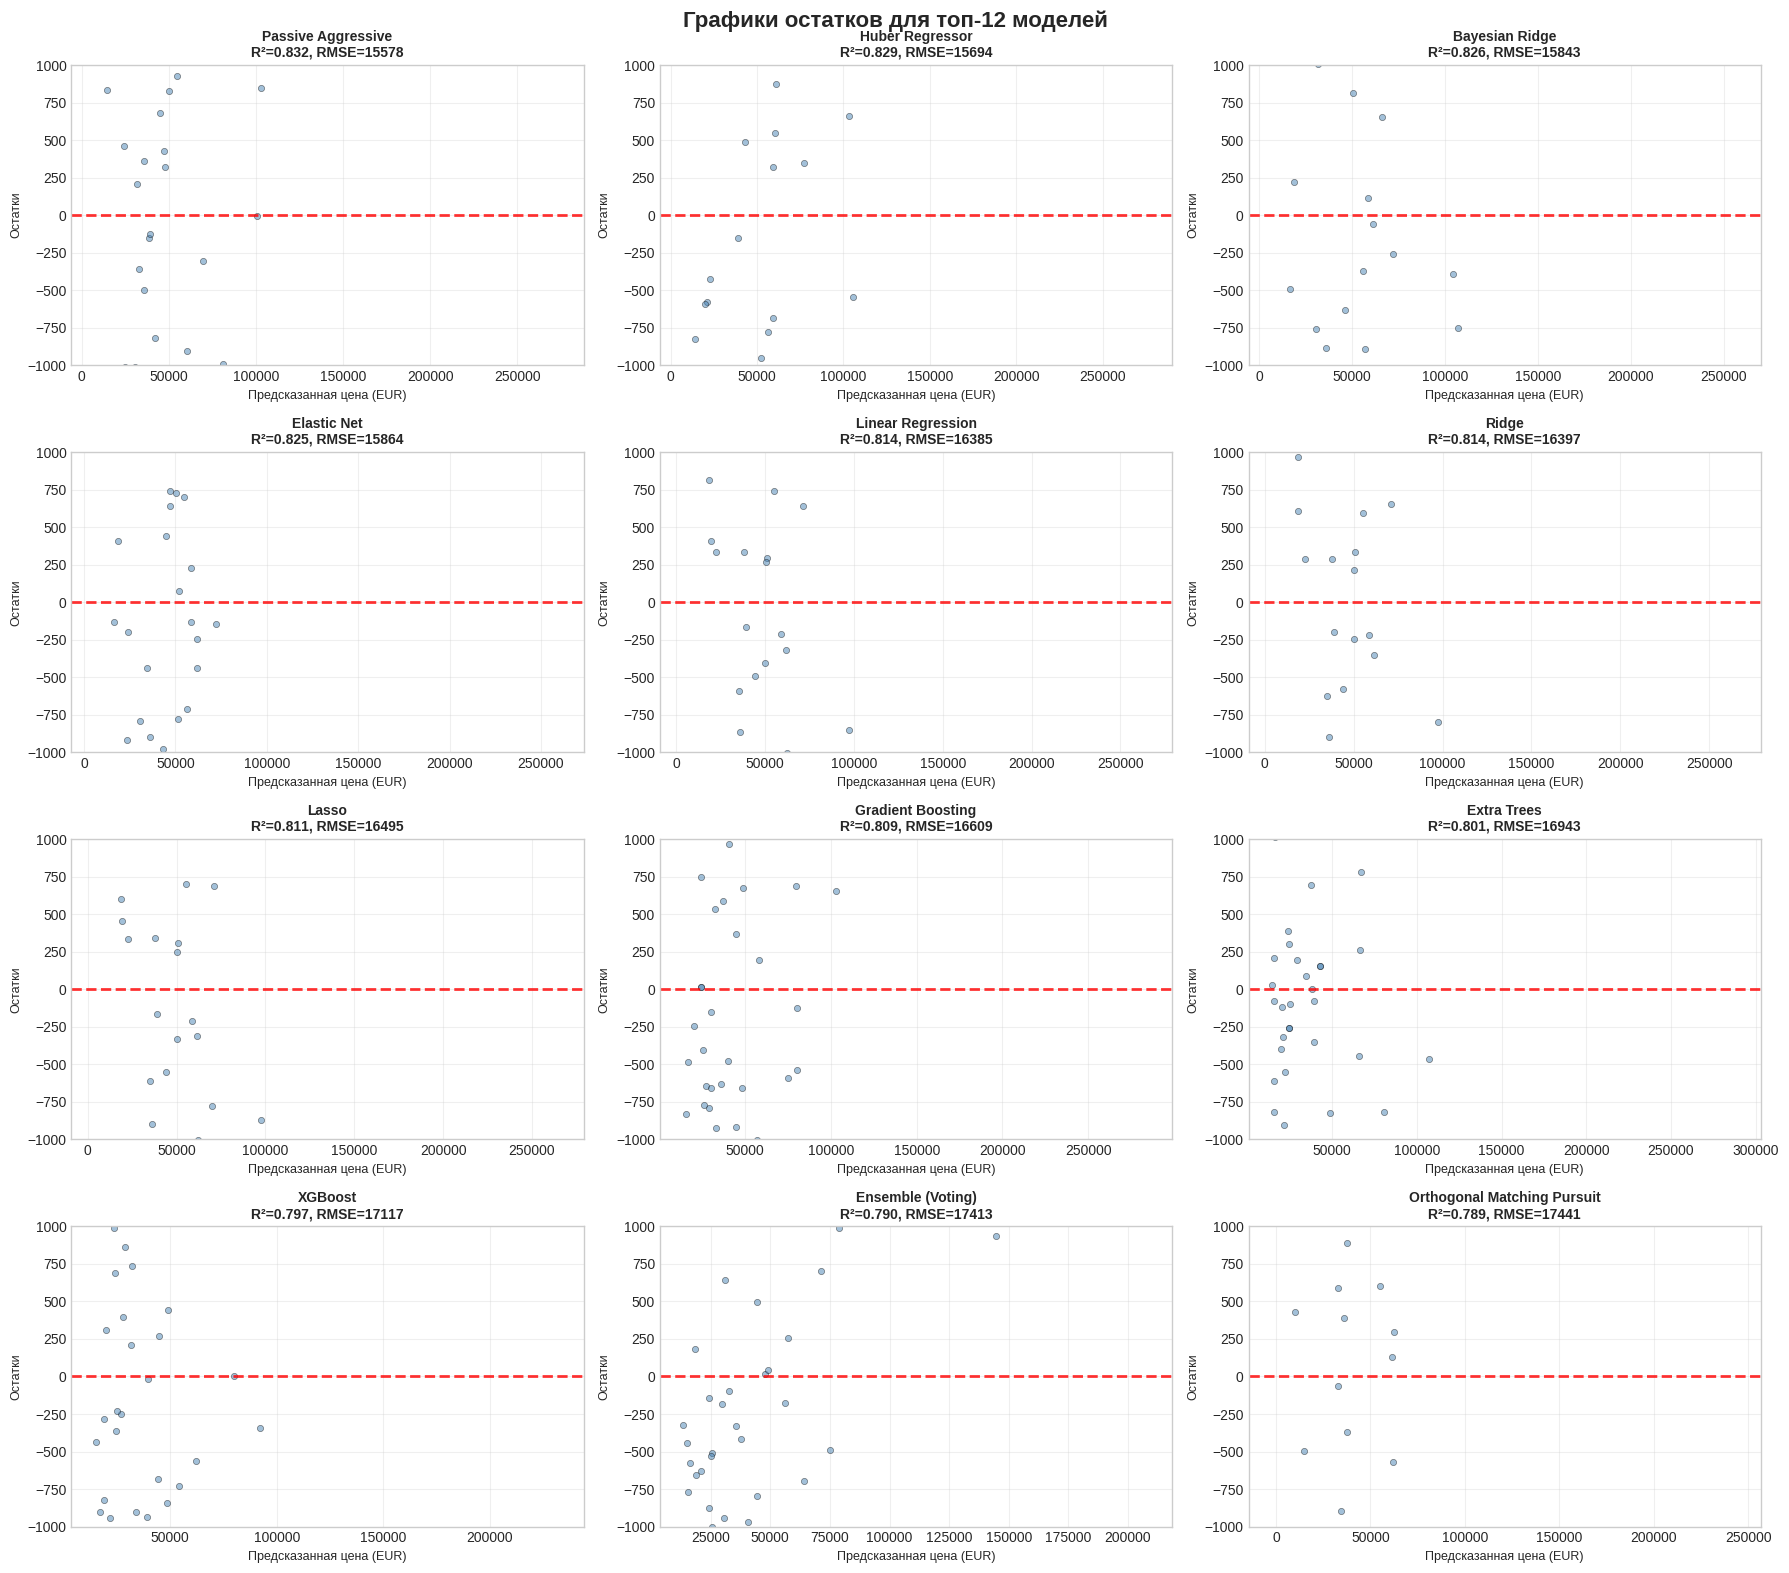

✓ Сохранен: laptop_residuals_box_violin.png


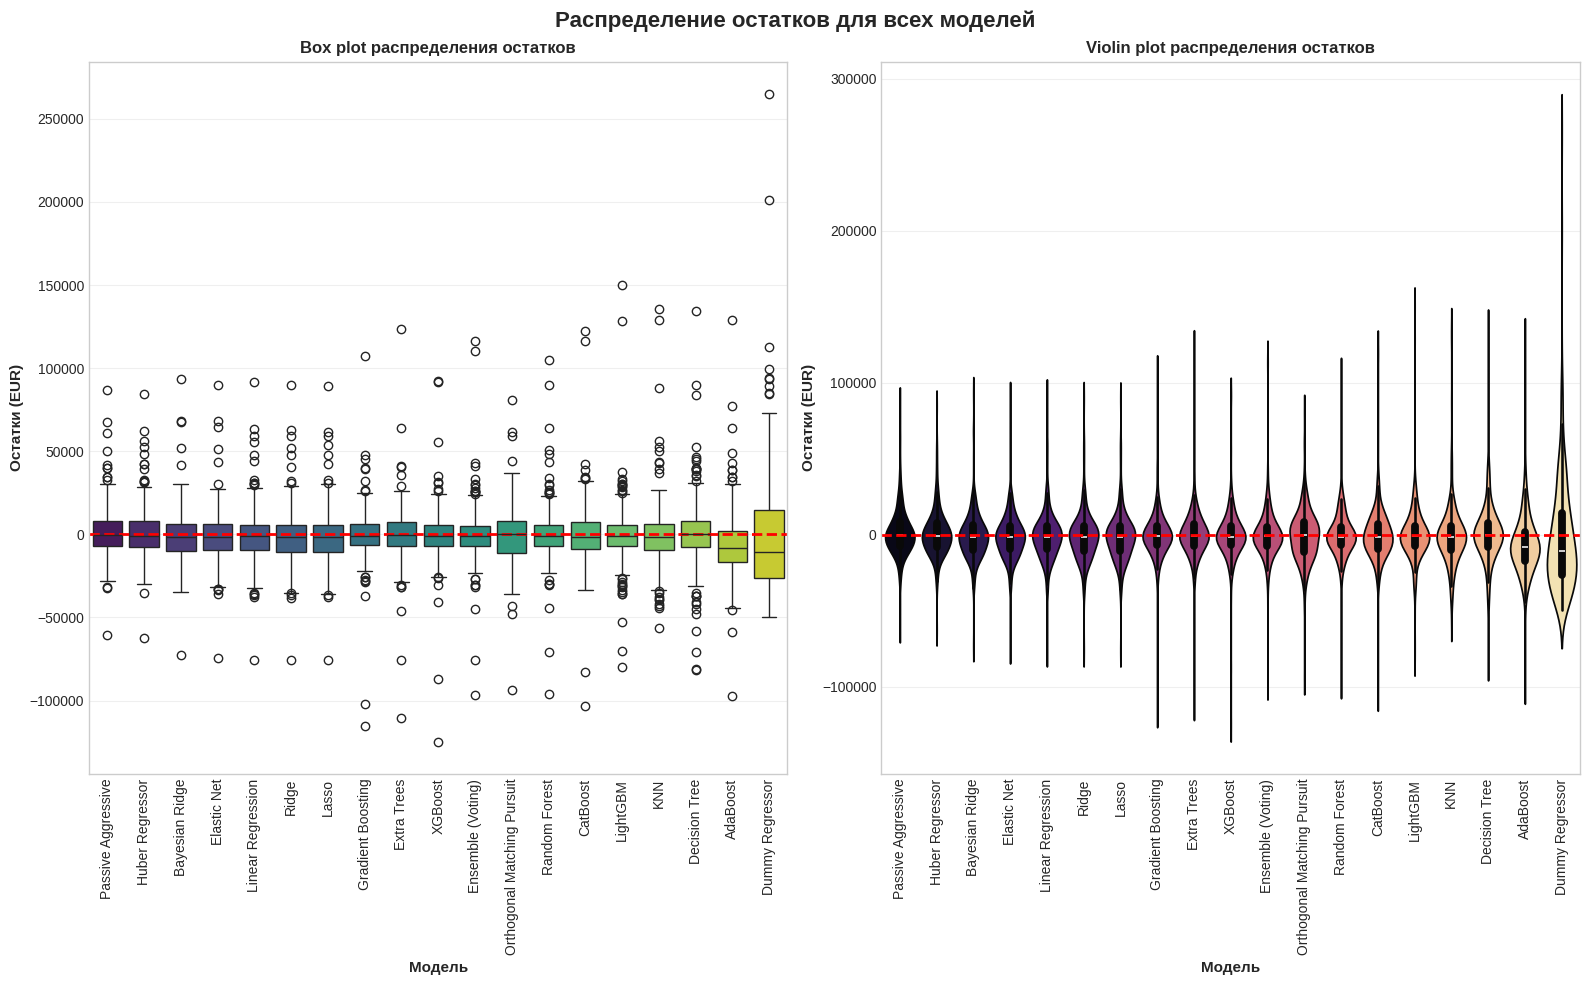

✓ Сохранен: laptop_residuals_histograms_top5.png


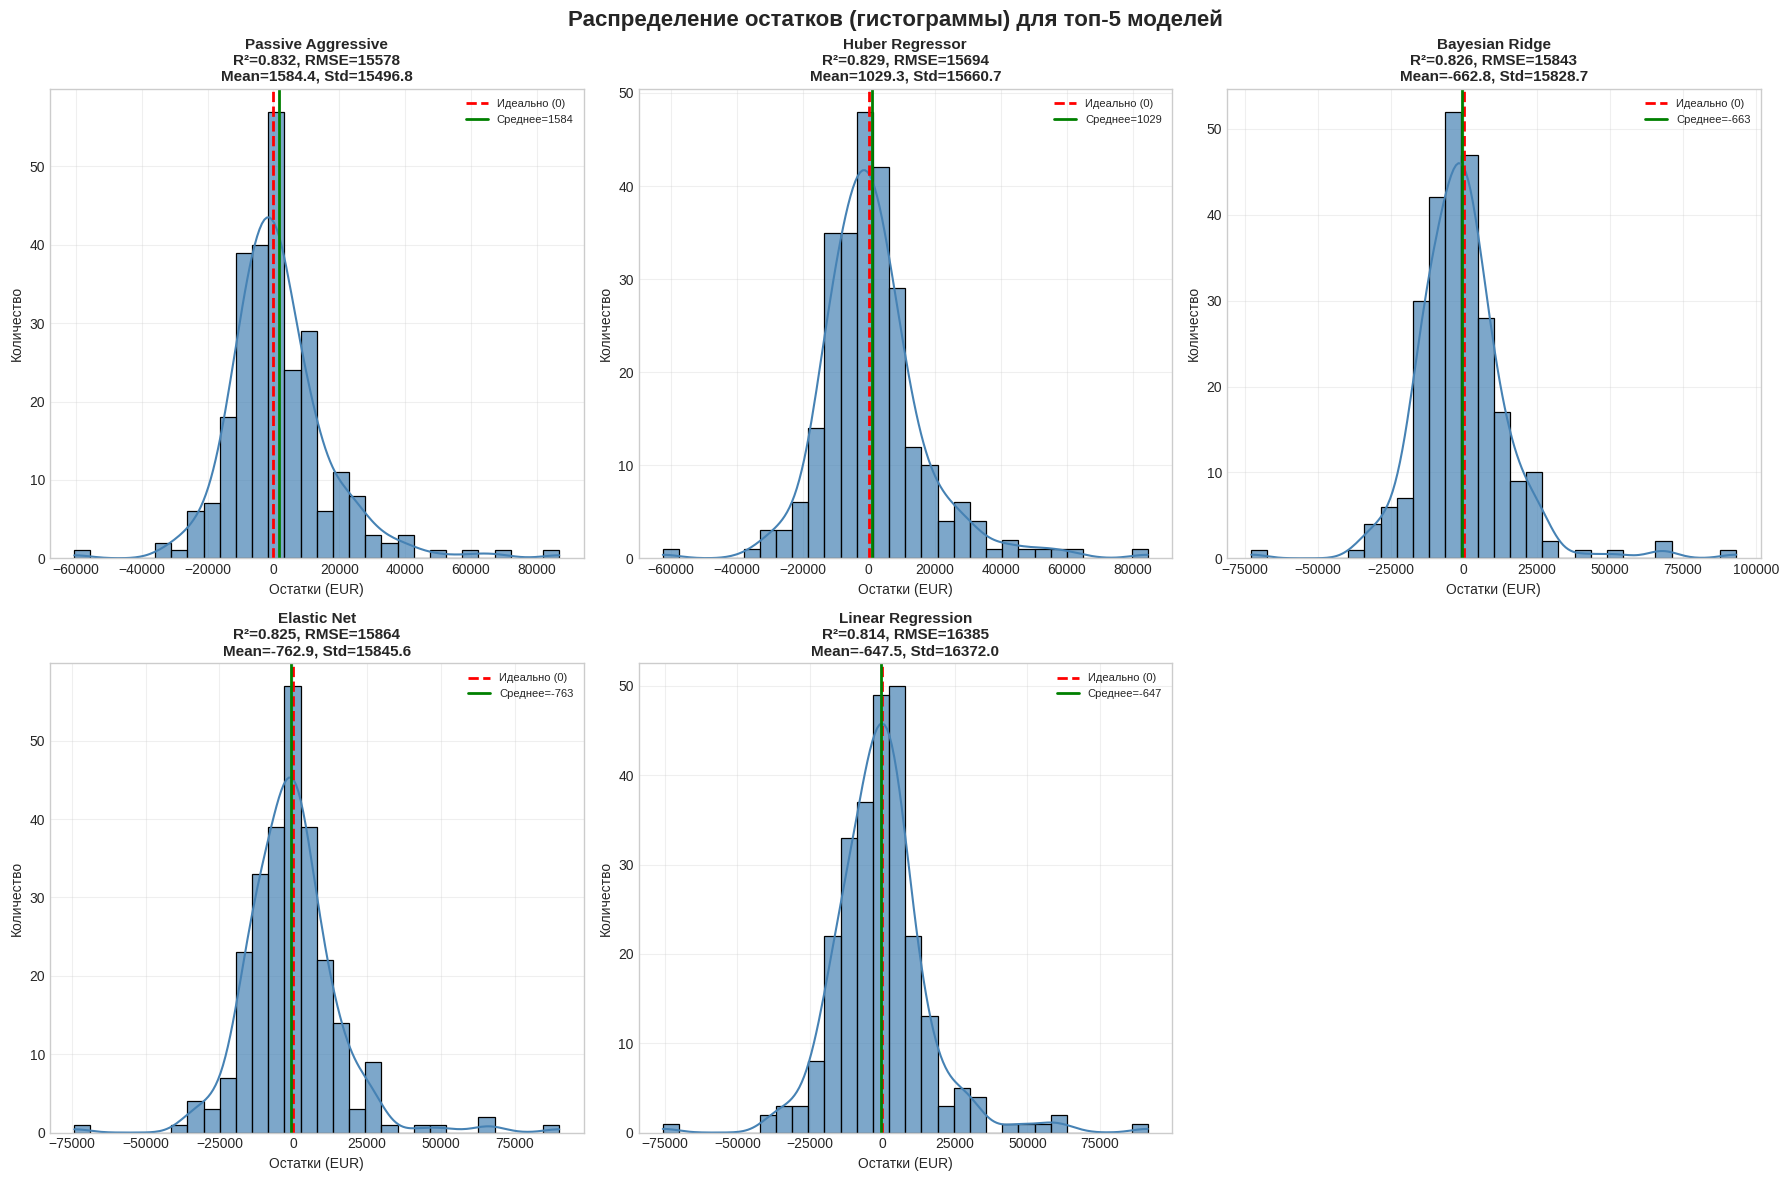

✓ Сохранен: laptop_residuals_statistics.png


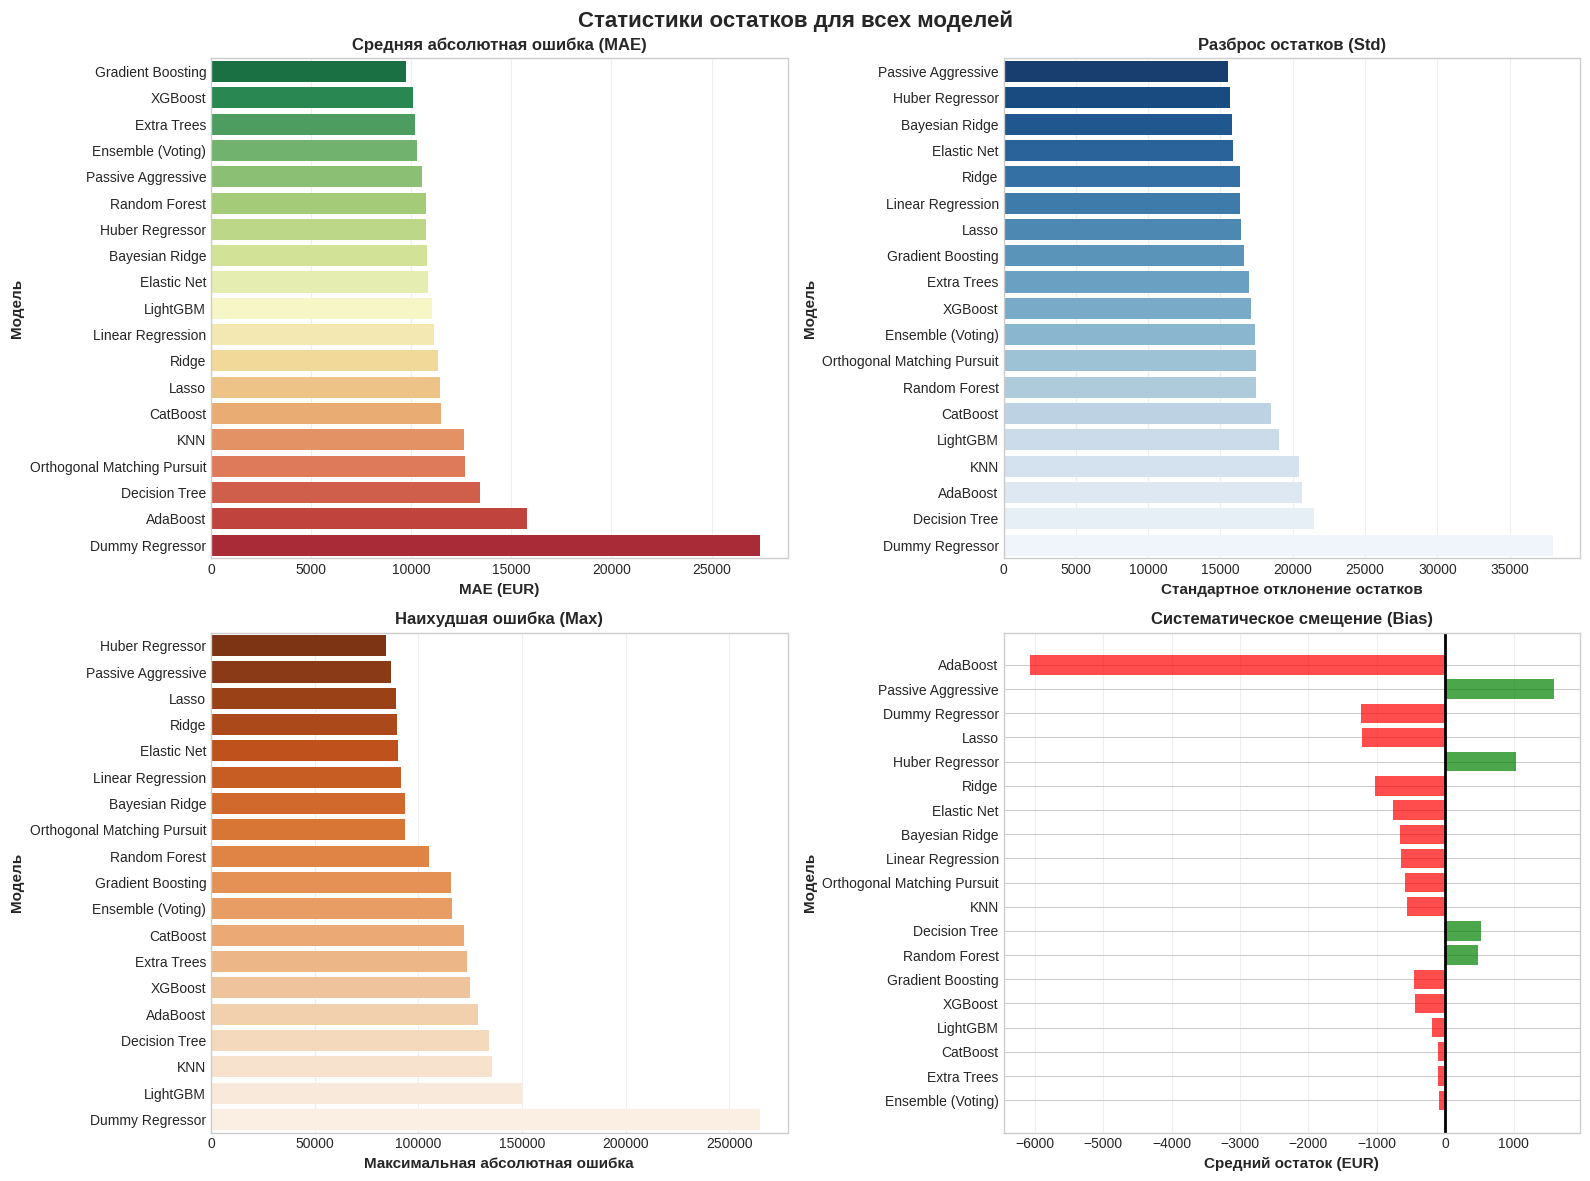


СТАТИСТИКИ ОСТАТКОВ ДЛЯ ВСЕХ МОДЕЛЕЙ

Топ-10 моделей по качеству остатков:
             Model       R2         RMSE          MAE  Mean Residual  Std Residual  Max Residual
Passive Aggressive 0.831704 15577.631373 10532.516009    1584.438317  15496.843369  86792.998680
   Huber Regressor 0.829170 15694.455384 10758.021281    1029.302703  15660.666197  84604.805947
    Bayesian Ridge 0.825931 15842.540159 10775.854008    -662.773034  15828.670526  93345.887912
       Elastic Net 0.825461 15863.914040 10827.613558    -762.941720  15845.557378  90120.812299
 Linear Regression 0.813813 16384.752843 11147.873676    -647.454698  16371.955538  91501.414524
             Ridge 0.813532 16397.083960 11349.231314   -1027.490886  16364.859452  89725.087395
             Lasso 0.811307 16494.630154 11431.667344   -1220.419260  16449.419465  89409.365134
 Gradient Boosting 0.808685 16608.850979  9752.443006    -453.994449  16602.644966 115605.034639
       Extra Trees 0.800900 16943.376764 10204.3899

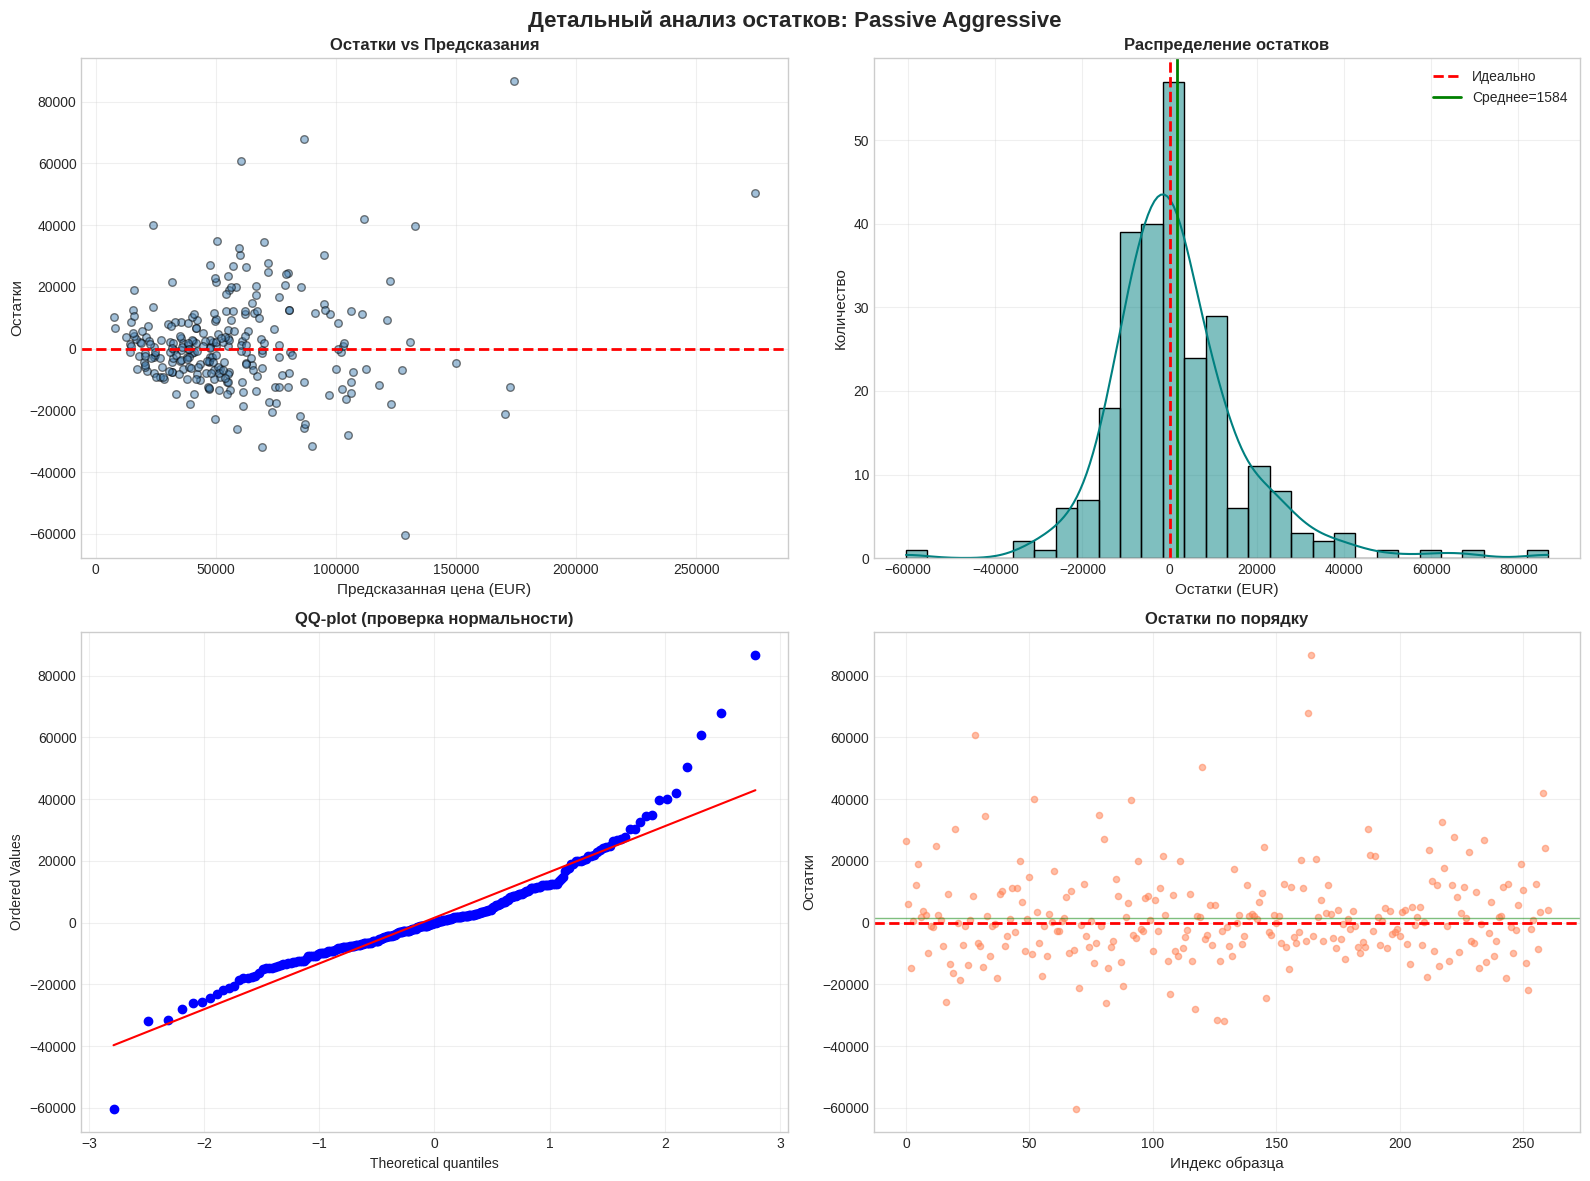


ИНТЕРПРЕТАЦИЯ ГРАФИКОВ ОСТАТКОВ

ЧТО ПОКАЗЫВАЮТ ГРАФИКИ ОСТАТКОВ:

1. СЕТКА ГРАФИКОВ (laptop_residuals_grid_top12.png):
   - Показывает scatter plot остатков для топ-12 моделей
   - Идеальная модель: точки случайно разбросаны вокруг красной линии y=0
   - Паттерны (воронки, кривые): модель не улавливает зависимости

2. BOX PLOT И VIOLIN PLOT (laptop_residuals_box_violin.png):
   - Показывает распределение остатков для всех моделей
   - Узкий ящик = малый разброс ошибок (хорошо)
   - Симметрия вокруг 0 = нет систематического смещения
   - Выбросы (точки за пределами усов) = экстремальные ошибки

3. ГИСТОГРАММЫ (laptop_residuals_histograms_top5.png):
   - Показывает форму распределения остатков
   - Идеально: колокол (нормальное распределение) вокруг 0
   - Скошенность = систематическое смещение модели

4. СТАТИСТИКИ (laptop_residuals_statistics.png):
   - MAE: средняя абсолютная ошибка (чем меньше, тем лучше)
   - Std: стандартное отклонение остатков (разброс)
   - Max: максимальная ош

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Линейные модели
from sklearn.linear_model import (
    LinearRegression, Ridge, Lasso, ElasticNet,
    BayesianRidge, HuberRegressor, OrthogonalMatchingPursuit,
    PassiveAggressiveRegressor
)

# Метод ближайших соседей
from sklearn.neighbors import KNeighborsRegressor

# Деревья
from sklearn.tree import DecisionTreeRegressor

# Ансамбли
from sklearn.ensemble import (
    RandomForestRegressor, ExtraTreesRegressor,
    GradientBoostingRegressor, AdaBoostRegressor, VotingRegressor
)

# Фиктивный регрессор
from sklearn.dummy import DummyRegressor

# Градиентный бустинг
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor

import warnings
warnings.filterwarnings('ignore')

# Настройка стиля
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# ============================================================================
# 1. ЗАГРУЗКА И ПОДГОТОВКА ДАННЫХ
# ============================================================================

print("=" * 80)
print("ЗАГРУЗКА ДАННЫХ")
print("=" * 80)

url = "https://raw.githubusercontent.com/campusx-official/laptop-price-predictor-regression-project/main/laptop_data.csv"
df = pd.read_csv(url)
print(f"Размер датасета: {df.shape[0]} строк, {df.shape[1]} столбцов")

# Подготовка данных
if 'Ram' in df.columns:
    df['Ram_GB'] = df['Ram'].str.extract(r'(\d+)').astype(float)
if 'Weight' in df.columns:
    df['Weight_kg'] = df['Weight'].str.extract(r'(\d+\.?\d*)').astype(float)
if 'Memory' in df.columns:
    df['Memory_Type'] = df['Memory'].apply(
        lambda x: 'SSD' if 'SSD' in str(x) else ('HDD' if 'HDD' in str(x) else 'Flash')
    )
    df['Memory_Size'] = df['Memory'].str.extract(r'(\d+)').astype(float)
if 'ScreenResolution' in df.columns:
    df['Screen_Width'] = df['ScreenResolution'].str.extract(r'(\d+)x\d+').astype(float)
    df['Screen_Height'] = df['ScreenResolution'].str.extract(r'\d+x(\d+)').astype(float)

columns_to_drop = ['Ram', 'Weight', 'Memory', 'ScreenResolution']
existing_columns = [col for col in columns_to_drop if col in df.columns]
if existing_columns:
    df = df.drop(existing_columns, axis=1)
if 'Product' in df.columns:
    df = df.drop('Product', axis=1)

X = df.drop('Price', axis=1)
y = df['Price']

X_encoded = pd.get_dummies(X, drop_first=True)

def clean_column_name(col):
    col_str = str(col)
    col_clean = re.sub(r'[^A-Za-z0-9_]', '_', col_str)
    col_clean = re.sub(r'_+', '_', col_clean)
    col_clean = col_clean.strip('_')
    return col_clean if col_clean else 'feature'

X_encoded.columns = [clean_column_name(col) for col in X_encoded.columns]

seen = {}
new_columns = []
for col in X_encoded.columns:
    if col in seen:
        seen[col] += 1
        new_columns.append(f"{col}_{seen[col]}")
    else:
        seen[col] = 0
        new_columns.append(col)
X_encoded.columns = new_columns

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train: {X_train.shape[0]}, Test: {X_test.shape[0]}")

# ============================================================================
# 2. ИНИЦИАЛИЗАЦИЯ МОДЕЛЕЙ
# ============================================================================

models_scaled = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0, random_state=42),
    'Lasso': Lasso(alpha=0.1, random_state=42),
    'Elastic Net': ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=42),
    'Bayesian Ridge': BayesianRidge(),
    'Huber Regressor': HuberRegressor(),
    'Orthogonal Matching Pursuit': OrthogonalMatchingPursuit(),
    'Passive Aggressive': PassiveAggressiveRegressor(random_state=42, max_iter=1000),
    'KNN': KNeighborsRegressor(n_neighbors=5),
    'Dummy Regressor': DummyRegressor(strategy='mean'),
}

models_unscaled = {
    'Decision Tree': DecisionTreeRegressor(max_depth=10, random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1),
    'Extra Trees': ExtraTreesRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42),
    'AdaBoost': AdaBoostRegressor(n_estimators=100, learning_rate=0.1, random_state=42),
    'XGBoost': xgb.XGBRegressor(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42, verbosity=0),
    'LightGBM': lgb.LGBMRegressor(n_estimators=100, max_depth=10, learning_rate=0.1, random_state=42, verbose=-1),
    'CatBoost': CatBoostRegressor(iterations=100, depth=6, learning_rate=0.1, random_state=42, verbose=0),
}

ensemble_base = [
    ('rf', RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)),
    ('xgb', xgb.XGBRegressor(n_estimators=50, random_state=42, verbosity=0)),
    ('lgbm', lgb.LGBMRegressor(n_estimators=50, random_state=42, verbose=-1)),
]
models_unscaled['Ensemble (Voting)'] = VotingRegressor(estimators=ensemble_base)

models = {}
models.update(models_scaled)
models.update(models_unscaled)

# ============================================================================
# 3. ОБУЧЕНИЕ И СОХРАНЕНИЕ ОСТАТКОВ
# ============================================================================

print("\n" + "=" * 80)
print("ОБУЧЕНИЕ МОДЕЛЕЙ И РАСЧЕТ ОСТАТКОВ")
print("=" * 80)

all_residuals = {}
all_predictions = {}
results = []

for name, model in models.items():
    print(f"Обучение: {name}...", end=" ")

    if name in models_scaled:
        X_tr, X_te = X_train_scaled, X_test_scaled
    else:
        X_tr, X_te = X_train, X_test

    try:
        model.fit(X_tr, y_train)
        y_pred = model.predict(X_te)
        residuals = y_test.values - y_pred

        all_residuals[name] = residuals
        all_predictions[name] = y_pred

        mae = mean_absolute_error(y_test, y_pred)
        mse = mean_squared_error(y_test, y_pred)
        rmse = np.sqrt(mse)
        r2 = r2_score(y_test, y_pred)

        results.append({
            'Model': name,
            'MAE': mae,
            'RMSE': rmse,
            'R2': r2,
            'Mean Residual': residuals.mean(),
            'Std Residual': residuals.std(),
            'Max Residual': np.abs(residuals).max()
        })

        print(f"R2 = {r2:.4f}")
    except Exception as e:
        print(f"ОШИБКА: {e}")

results_df = pd.DataFrame(results)
results_df = results_df.sort_values('R2', ascending=False).reset_index(drop=True)

# ============================================================================
# 4. ВИЗУАЛИЗАЦИЯ 1: СЕТКА ГРАФИКОВ ОСТАТКОВ
# ============================================================================

print("\n" + "=" * 80)
print("СОЗДАНИЕ ГРАФИКОВ ОСТАТКОВ")
print("=" * 80)

# Топ-12 моделей по R2 для детальной визуализации
top_models = results_df.head(12)['Model'].tolist()

fig, axes = plt.subplots(4, 3, figsize=(18, 16))
fig.suptitle('Графики остатков для топ-12 моделей', fontsize=16, fontweight='bold')
axes = axes.flatten()

for idx, model_name in enumerate(top_models):
    ax = axes[idx]
    residuals = all_residuals[model_name]
    predictions = all_predictions[model_name]
    r2 = results_df[results_df['Model'] == model_name]['R2'].values[0]
    rmse = results_df[results_df['Model'] == model_name]['RMSE'].values[0]

    # Scatter plot остатков
    ax.scatter(predictions, residuals, alpha=0.5, s=20, color='steelblue', edgecolors='black', linewidth=0.5)
    ax.axhline(0, color='red', linestyle='--', linewidth=2, alpha=0.8)

    ax.set_xlabel('Предсказанная цена (EUR)', fontsize=9)
    ax.set_ylabel('Остатки', fontsize=9)
    ax.set_title(f'{model_name}\nR²={r2:.3f}, RMSE={rmse:.0f}', fontsize=10, fontweight='bold')
    ax.grid(True, alpha=0.3)

    # Установить одинаковые пределы по Y для сравнения
    ax.set_ylim(-1000, 1000)

plt.tight_layout()
plt.savefig('laptop_residuals_grid_top12.png', dpi=150, bbox_inches='tight')
print("✓ Сохранен: laptop_residuals_grid_top12.png")
plt.show()

# ============================================================================
# 5. ВИЗУАЛИЗАЦИЯ 2: BOX PLOT СРАВНЕНИЕ ОСТАТКОВ
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 10))
fig.suptitle('Распределение остатков для всех моделей', fontsize=16, fontweight='bold')

# Box plot
ax1 = axes[0]
residuals_df = pd.DataFrame(all_residuals)
# Перевернуть данные для boxplot
residuals_melted = residuals_df.melt(var_name='Model', value_name='Residual')
# Сортировать модели по R2
model_order = results_df.sort_values('R2', ascending=False)['Model'].tolist()

sns.boxplot(data=residuals_melted, x='Model', y='Residual', order=model_order, ax=ax1, palette='viridis')
ax1.set_xlabel('Модель', fontsize=11, fontweight='bold')
ax1.set_ylabel('Остатки (EUR)', fontsize=11, fontweight='bold')
ax1.set_title('Box plot распределения остатков', fontsize=12, fontweight='bold')
ax1.tick_params(axis='x', rotation=90)
ax1.grid(True, alpha=0.3, axis='y')
ax1.axhline(0, color='red', linestyle='--', linewidth=2)

# Violin plot
ax2 = axes[1]
sns.violinplot(data=residuals_melted, x='Model', y='Residual', order=model_order, ax=ax2, palette='magma')
ax2.set_xlabel('Модель', fontsize=11, fontweight='bold')
ax2.set_ylabel('Остатки (EUR)', fontsize=11, fontweight='bold')
ax2.set_title('Violin plot распределения остатков', fontsize=12, fontweight='bold')
ax2.tick_params(axis='x', rotation=90)
ax2.grid(True, alpha=0.3, axis='y')
ax2.axhline(0, color='red', linestyle='--', linewidth=2)

plt.tight_layout()
plt.savefig('laptop_residuals_box_violin.png', dpi=150, bbox_inches='tight')
print("✓ Сохранен: laptop_residuals_box_violin.png")
plt.show()

# ============================================================================
# 6. ВИЗУАЛИЗАЦИЯ 3: ГИСТОГРАММЫ ОСТАТКОВ ДЛЯ ТОП-5 МОДЕЛЕЙ
# ============================================================================

top5_models = results_df.head(5)['Model'].tolist()

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Распределение остатков (гистограммы) для топ-5 моделей', fontsize=16, fontweight='bold')
axes = axes.flatten()

for idx, model_name in enumerate(top5_models):
    ax = axes[idx]
    residuals = all_residuals[model_name]
    r2 = results_df[results_df['Model'] == model_name]['R2'].values[0]
    rmse = results_df[results_df['Model'] == model_name]['RMSE'].values[0]
    mean_res = residuals.mean()
    std_res = residuals.std()

    # Гистограмма
    sns.histplot(residuals, bins=30, kde=True, ax=ax, color='steelblue', alpha=0.7)
    ax.axvline(0, color='red', linestyle='--', linewidth=2, label='Идеально (0)')
    ax.axvline(mean_res, color='green', linestyle='-', linewidth=2, label=f'Среднее={mean_res:.0f}')

    ax.set_xlabel('Остатки (EUR)', fontsize=10)
    ax.set_ylabel('Количество', fontsize=10)
    ax.set_title(f'{model_name}\nR²={r2:.3f}, RMSE={rmse:.0f}\nMean={mean_res:.1f}, Std={std_res:.1f}',
                 fontsize=11, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

# Удалить последний пустой subplot
axes[5].set_visible(False)

plt.tight_layout()
plt.savefig('laptop_residuals_histograms_top5.png', dpi=150, bbox_inches='tight')
print("✓ Сохранен: laptop_residuals_histograms_top5.png")
plt.show()

# ============================================================================
# 7. ВИЗУАЛИЗАЦИЯ 4: СТАТИСТИКИ ОСТАТКОВ
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Статистики остатков для всех моделей', fontsize=16, fontweight='bold')

# Mean Absolute Residual
ax1 = axes[0, 0]
results_df_sorted = results_df.sort_values('MAE', ascending=True)
sns.barplot(data=results_df_sorted, x='MAE', y='Model', ax=ax1, palette='RdYlGn_r')
ax1.set_xlabel('MAE (EUR)', fontsize=11, fontweight='bold')
ax1.set_ylabel('Модель', fontsize=11, fontweight='bold')
ax1.set_title('Средняя абсолютная ошибка (MAE)', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='x')

# Std of Residuals
ax2 = axes[0, 1]
results_df_sorted = results_df.sort_values('Std Residual', ascending=True)
sns.barplot(data=results_df_sorted, x='Std Residual', y='Model', ax=ax2, palette='Blues_r')
ax2.set_xlabel('Стандартное отклонение остатков', fontsize=11, fontweight='bold')
ax2.set_ylabel('Модель', fontsize=11, fontweight='bold')
ax2.set_title('Разброс остатков (Std)', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='x')

# Max Absolute Residual
ax3 = axes[1, 0]
results_df_sorted = results_df.sort_values('Max Residual', ascending=True)
sns.barplot(data=results_df_sorted, x='Max Residual', y='Model', ax=ax3, palette='Oranges_r')
ax3.set_xlabel('Максимальная абсолютная ошибка', fontsize=11, fontweight='bold')
ax3.set_ylabel('Модель', fontsize=11, fontweight='bold')
ax3.set_title('Наихудшая ошибка (Max)', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3, axis='x')

# Mean Residual (Bias)
ax4 = axes[1, 1]
results_df_sorted = results_df.sort_values('Mean Residual', key=abs, ascending=True)
colors = ['green' if x >= 0 else 'red' for x in results_df_sorted['Mean Residual']]
ax4.barh(results_df_sorted['Model'], results_df_sorted['Mean Residual'], color=colors, alpha=0.7)
ax4.axvline(0, color='black', linestyle='-', linewidth=2)
ax4.set_xlabel('Средний остаток (EUR)', fontsize=11, fontweight='bold')
ax4.set_ylabel('Модель', fontsize=11, fontweight='bold')
ax4.set_title('Систематическое смещение (Bias)', fontsize=12, fontweight='bold')
ax4.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('laptop_residuals_statistics.png', dpi=150, bbox_inches='tight')
print("✓ Сохранен: laptop_residuals_statistics.png")
plt.show()

# ============================================================================
# 8. ТАБЛИЦА СТАТИСТИК
# ============================================================================

print("\n" + "=" * 80)
print("СТАТИСТИКИ ОСТАТКОВ ДЛЯ ВСЕХ МОДЕЛЕЙ")
print("=" * 80)

print("\nТоп-10 моделей по качеству остатков:")
print(results_df[['Model', 'R2', 'RMSE', 'MAE', 'Mean Residual', 'Std Residual', 'Max Residual']].head(10).to_string(index=False))

# ============================================================================
# 9. АНАЛИЗ ЛУЧШЕЙ МОДЕЛИ
# ============================================================================

print("\n" + "=" * 80)
print("ДЕТАЛЬНЫЙ АНАЛИЗ ЛУЧШЕЙ МОДЕЛИ")
print("=" * 80)

best_model_name = results_df.iloc[0]['Model']
best_residuals = all_residuals[best_model_name]
best_predictions = all_predictions[best_model_name]

print(f"\nЛучшая модель: {best_model_name}")
print(f"  R² = {results_df.iloc[0]['R2']:.4f}")
print(f"  RMSE = {results_df.iloc[0]['RMSE']:.2f} EUR")
print(f"  MAE = {results_df.iloc[0]['MAE']:.2f} EUR")
print(f"  Средний остаток = {best_residuals.mean():.2f} EUR")
print(f"  Std остатка = {best_residuals.std():.2f} EUR")
print(f"  Макс. остаток = {np.abs(best_residuals).max():.2f} EUR")

# Найти выбросы
outlier_threshold = 3 * best_residuals.std()
outliers_mask = np.abs(best_residuals) > outlier_threshold
n_outliers = outliers_mask.sum()

print(f"\n  Выбросов (>3σ): {n_outliers} из {len(best_residuals)} ({n_outliers/len(best_residuals)*100:.1f}%)")

# График остатков для лучшей модели
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(f'Детальный анализ остатков: {best_model_name}', fontsize=16, fontweight='bold')

# Scatter plot
ax1 = axes[0, 0]
ax1.scatter(best_predictions, best_residuals, alpha=0.5, s=30, color='steelblue', edgecolors='black')
ax1.axhline(0, color='red', linestyle='--', linewidth=2)
ax1.set_xlabel('Предсказанная цена (EUR)', fontsize=11)
ax1.set_ylabel('Остатки', fontsize=11)
ax1.set_title('Остатки vs Предсказания', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)

# Histogram + KDE
ax2 = axes[0, 1]
sns.histplot(best_residuals, bins=30, kde=True, ax=ax2, color='teal')
ax2.axvline(0, color='red', linestyle='--', linewidth=2, label='Идеально')
ax2.axvline(best_residuals.mean(), color='green', linestyle='-', linewidth=2, label=f'Среднее={best_residuals.mean():.0f}')
ax2.set_xlabel('Остатки (EUR)', fontsize=11)
ax2.set_ylabel('Количество', fontsize=11)
ax2.set_title('Распределение остатков', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

# QQ plot
ax3 = axes[1, 0]
from scipy import stats
stats.probplot(best_residuals, dist="norm", plot=ax3)
ax3.set_title('QQ-plot (проверка нормальности)', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3)

# Остатки по индексу
ax4 = axes[1, 1]
ax4.scatter(range(len(best_residuals)), best_residuals, alpha=0.5, s=20, color='coral')
ax4.axhline(0, color='red', linestyle='--', linewidth=2)
ax4.axhline(best_residuals.mean(), color='green', linestyle='-', linewidth=1, alpha=0.5)
ax4.set_xlabel('Индекс образца', fontsize=11)
ax4.set_ylabel('Остатки', fontsize=11)
ax4.set_title('Остатки по порядку', fontsize=12, fontweight='bold')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'laptop_best_model_{best_model_name.replace(" ", "_")}_analysis.png', dpi=150, bbox_inches='tight')
print(f"\n✓ Сохранен: laptop_best_model_{best_model_name.replace(' ', '_')}_analysis.png")
plt.show()

# ============================================================================
# 10. ВЫВОДЫ
# ============================================================================

print("\n" + "=" * 80)
print("ИНТЕРПРЕТАЦИЯ ГРАФИКОВ ОСТАТКОВ")
print("=" * 80)

print("""
ЧТО ПОКАЗЫВАЮТ ГРАФИКИ ОСТАТКОВ:

1. СЕТКА ГРАФИКОВ (laptop_residuals_grid_top12.png):
   - Показывает scatter plot остатков для топ-12 моделей
   - Идеальная модель: точки случайно разбросаны вокруг красной линии y=0
   - Паттерны (воронки, кривые): модель не улавливает зависимости

2. BOX PLOT И VIOLIN PLOT (laptop_residuals_box_violin.png):
   - Показывает распределение остатков для всех моделей
   - Узкий ящик = малый разброс ошибок (хорошо)
   - Симметрия вокруг 0 = нет систематического смещения
   - Выбросы (точки за пределами усов) = экстремальные ошибки

3. ГИСТОГРАММЫ (laptop_residuals_histograms_top5.png):
   - Показывает форму распределения остатков
   - Идеально: колокол (нормальное распределение) вокруг 0
   - Скошенность = систематическое смещение модели

4. СТАТИСТИКИ (laptop_residuals_statistics.png):
   - MAE: средняя абсолютная ошибка (чем меньше, тем лучше)
   - Std: стандартное отклонение остатков (разброс)
   - Max: максимальная ошибка (наихудший случай)
   - Mean Residual: систематическое смещение (должно быть ≈ 0)

КРИТЕРИИ ХОРОШЕЙ МОДЕЛИ:
✓ Остатки случайно разбросаны вокруг 0
✓ Нет видимых паттернов (трендов, воронок)
✓ Распределение близко к нормальному (колокол)
✓ Средний остаток ≈ 0 (нет смещения)
✓ Малый разброс (Std)
✓ Мало выбросов

ЛУЧШАЯ МОДЕЛЬ: """ + best_model_name + """
  R² = """ + f"{results_df.iloc[0]['R2']:.4f}" + """
  Остатки показывают """ + ("отличное" if abs(best_residuals.mean()) < 10 else "хорошее") + """ качество предсказаний
""")

print("=" * 80)